# William Anthony Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

Clothing ID: Integer Categorical variable that refers to the specific piece being reviewed.
Age: Positive Integer variable of the reviewers age.
Title: String variable for the title of the review.
Review Text: String variable for the review body.
Positive Feedback Count: Positive Integer documenting the number of other customers who found this review positive.
Division Name: Categorical name of the product high level division.
Department Name: Categorical name of the product department name.
Class Name: Categorical name of the product class name.
The target:

Recommended IND: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [2]:
# import librarys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv(
    'reviews.csv',
)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


__The results from df.info suggest there are no missing values in this dataset.   We will still use imputer in our pipeline incase future data includes missing values.__

## Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


__In the cell below we split the data into Train and Test datasets.__

In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

__Below we separate the numerical and catagorical features.  "Review Text" is the only text feature.  Later, each will be treated with it's own pipeline.__

In [5]:
# numerical features are placed in num_features.
num_features = (
    X[[
        'Age',
        'Positive Feedback Count',
      ]].columns
)
print('The Numerical features are:', num_features)

# catagorical features are placed in cat_features.
cat_features = (
    X[[
        'Clothing ID',
        'Division Name',
        'Department Name',
        'Class Name',
    ]].columns
)
print('The Catagorical features are:', cat_features)

The Numerical features are: Index(['Age', 'Positive Feedback Count'], dtype='object')
The Catagorical features are: Index(['Clothing ID', 'Division Name', 'Department Name', 'Class Name'], dtype='object')


## Data Exploration

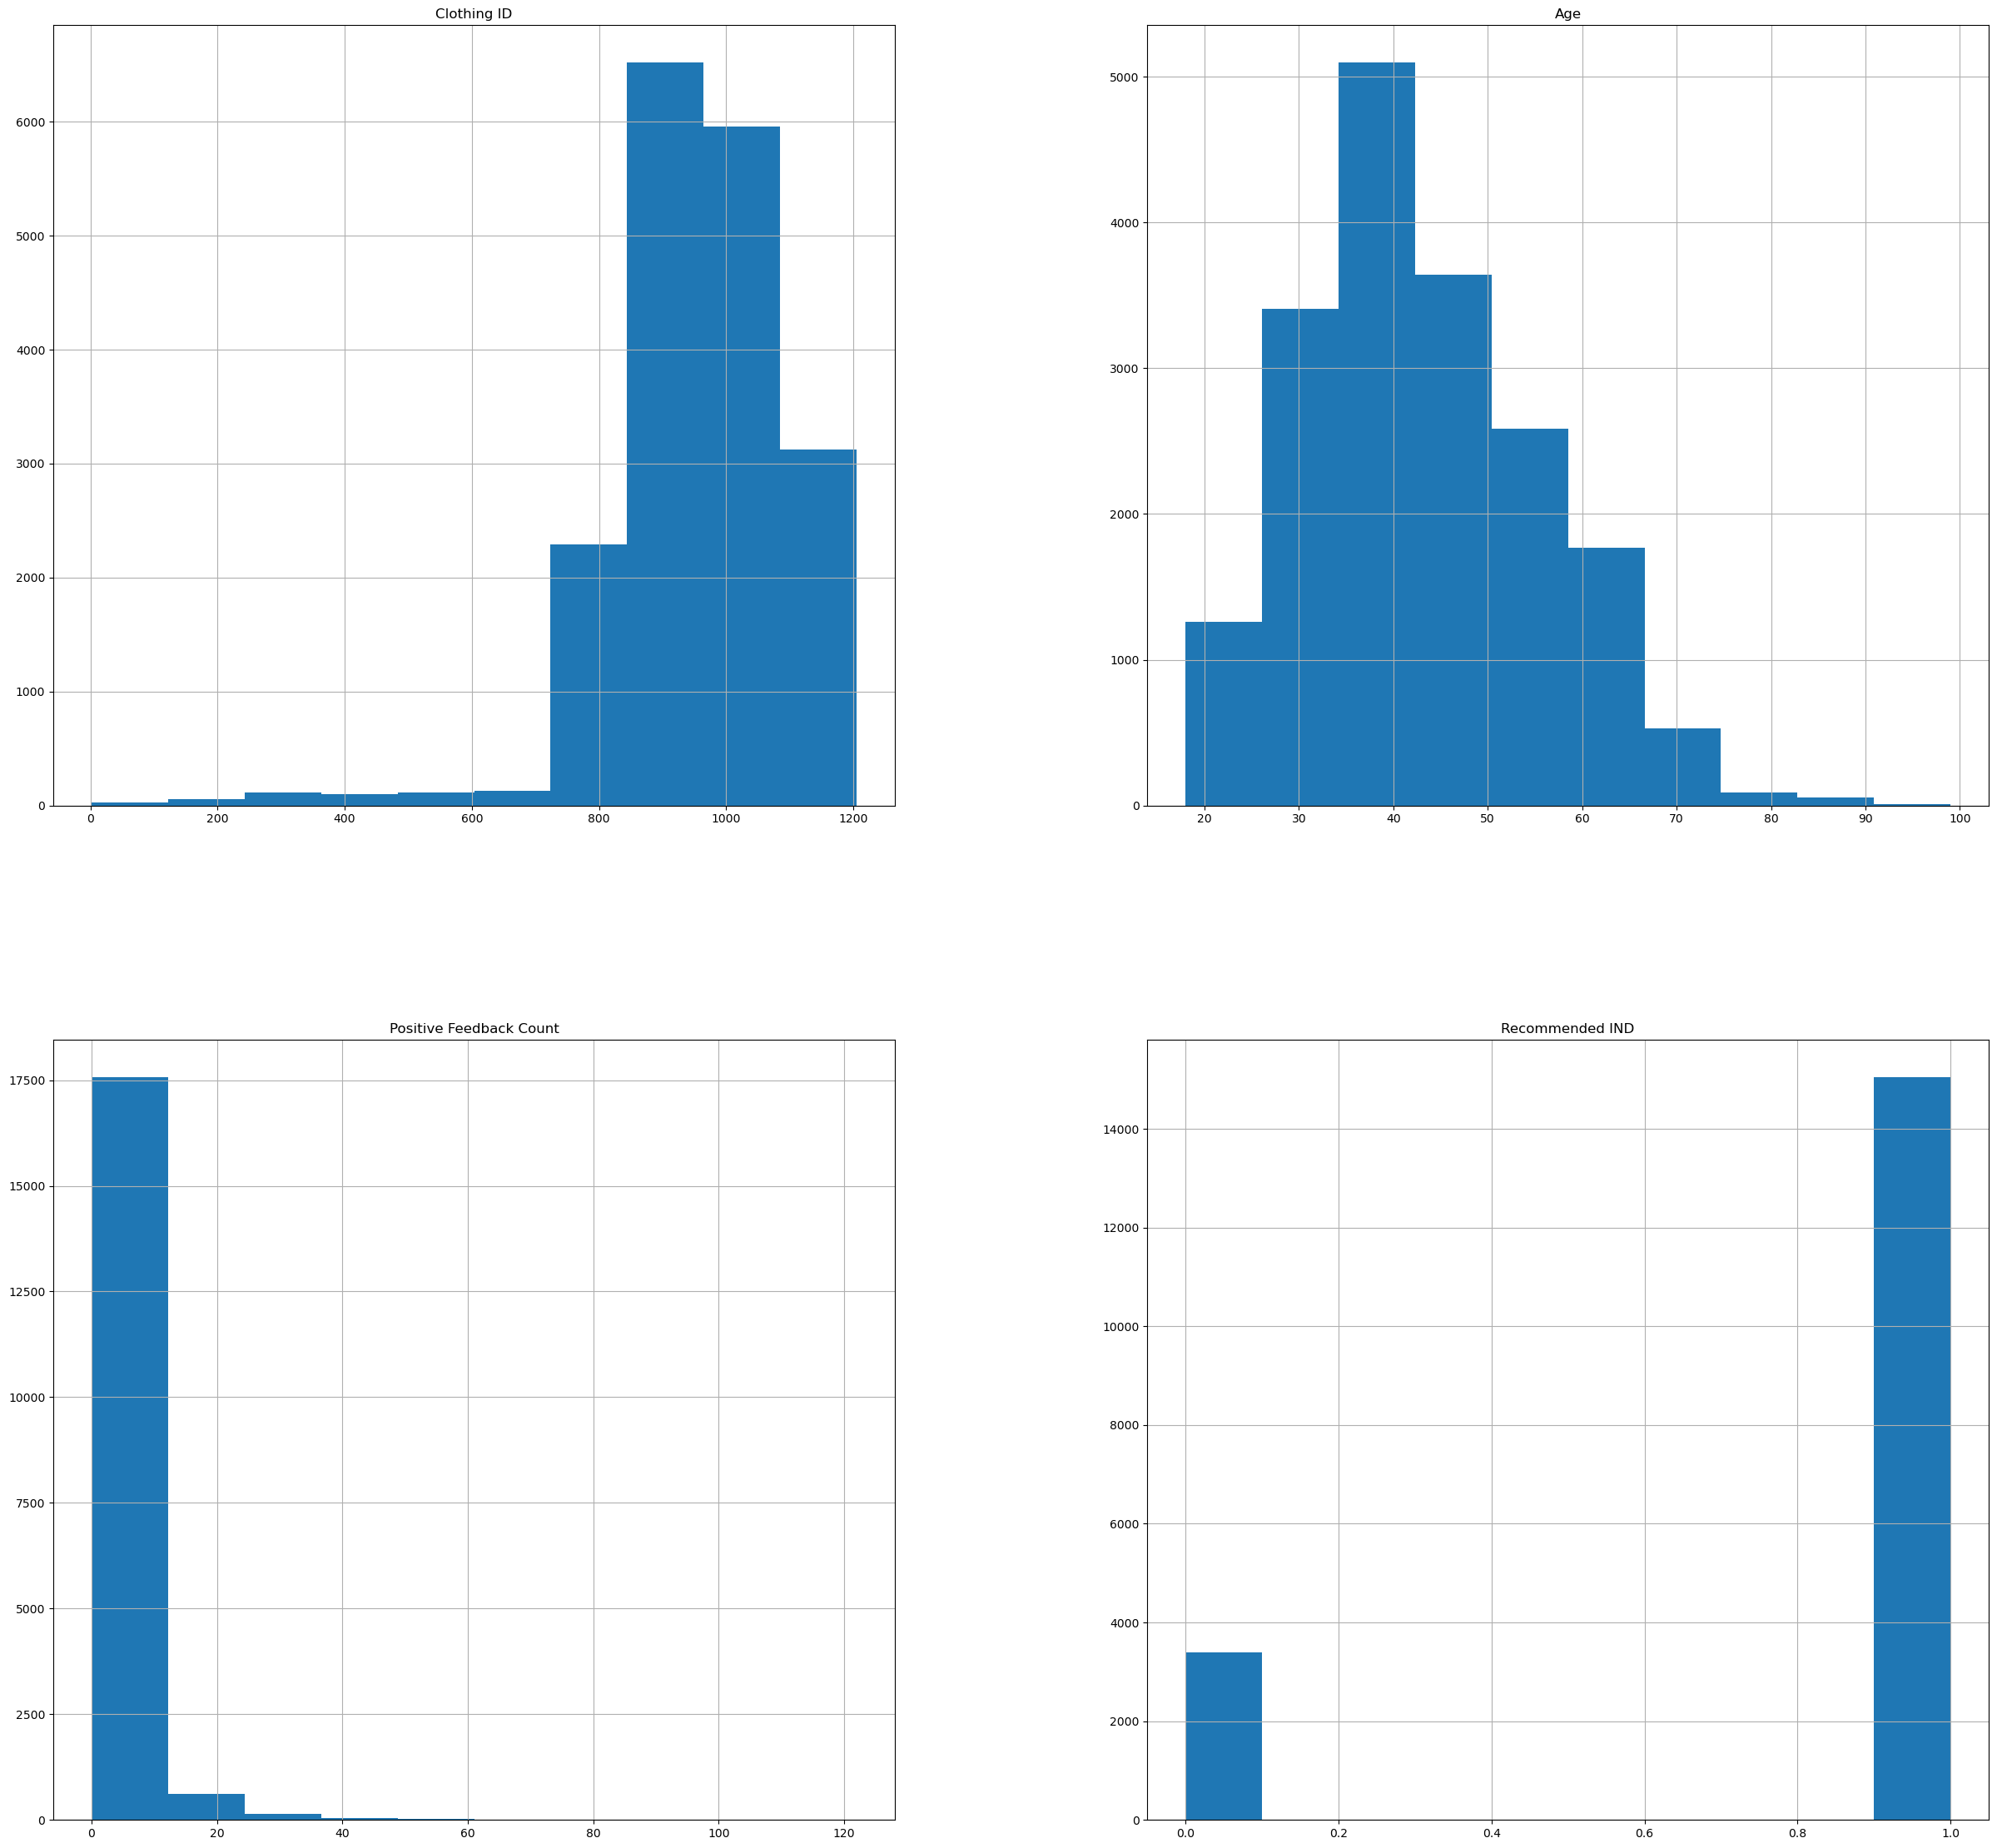

In [6]:
# histograms plots of the features with matplotlib to see their distributions
# We plot clothing ID, Age, Positivie Feedback Count, and Recommended IND.
df.hist(bins=10, figsize=(30, 28))
plt.show()

__The histograms above show that review age is skewed towarads older people.   Posotive Feedback count is very low for most reviews.  Significant is the imbalance between 0 and 1 rewiews.   There are a lot of 1 for Recommended and very few 0s.   This suggest a class imbalance that will have to be dealt with as Recommended IND is our target__

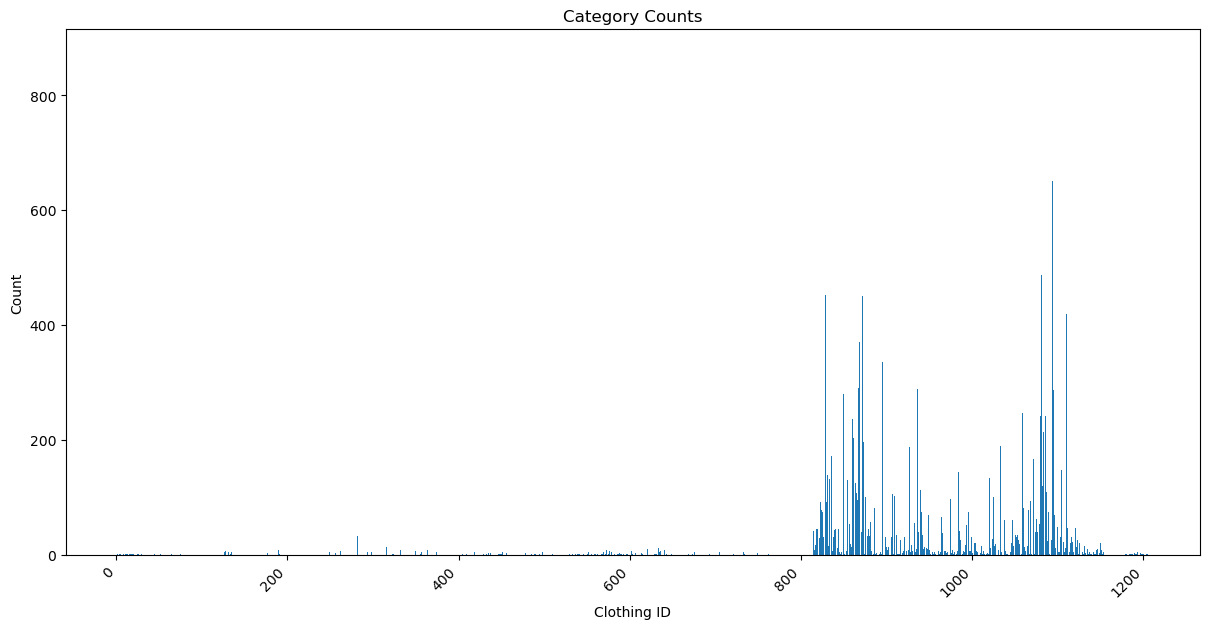

In [7]:
# Produce a graph to investigate the count for different Clothing ID
import matplotlib.pyplot as plt
from collections import Counter

plt.figure(figsize=(12, 6))

counts = dict(sorted(Counter(df['Clothing ID']).items(),
                     key=lambda x: x[1], reverse=True))

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.xlabel("Clothing ID")
plt.ylabel("Count")
plt.title("Category Counts")

plt.show()

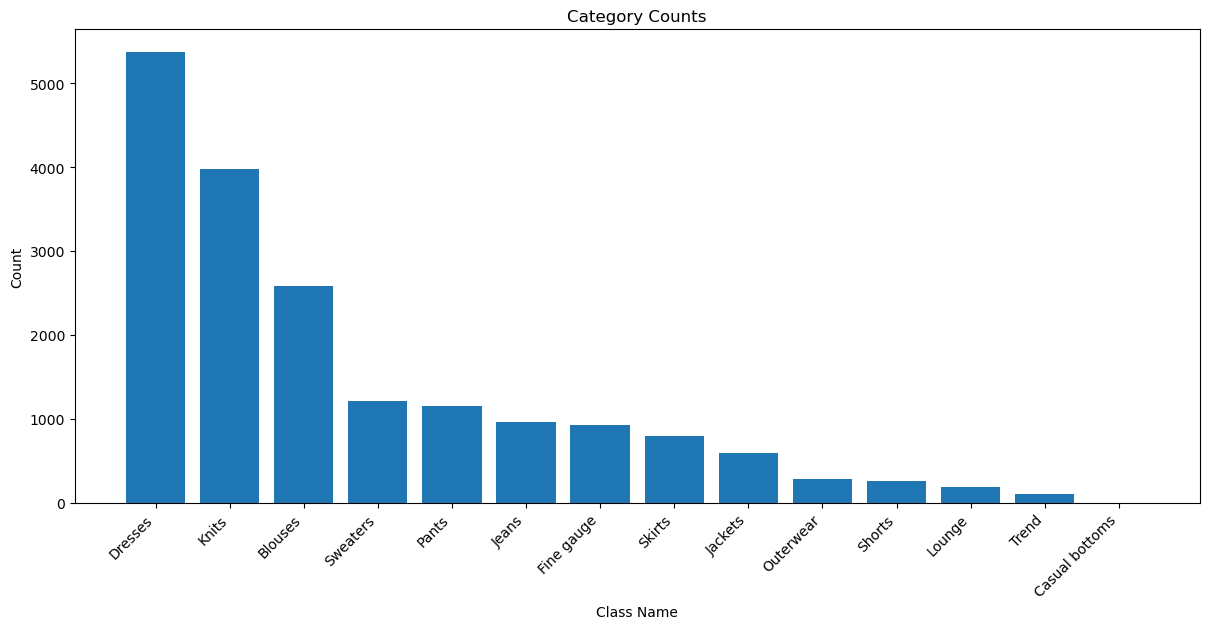

In [8]:
# Produce a graph to visualize the count of the different types for Class Name
plt.figure(figsize=(12, 6))

counts = dict(sorted(Counter(df['Class Name']).items(),
                     key=lambda x: x[1], reverse=True))

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.xlabel("Class Name")
plt.ylabel("Count")
plt.title("Category Counts")

plt.show()

__We see that majority of reviews are for Dresses followed by Knits and Blouses.__

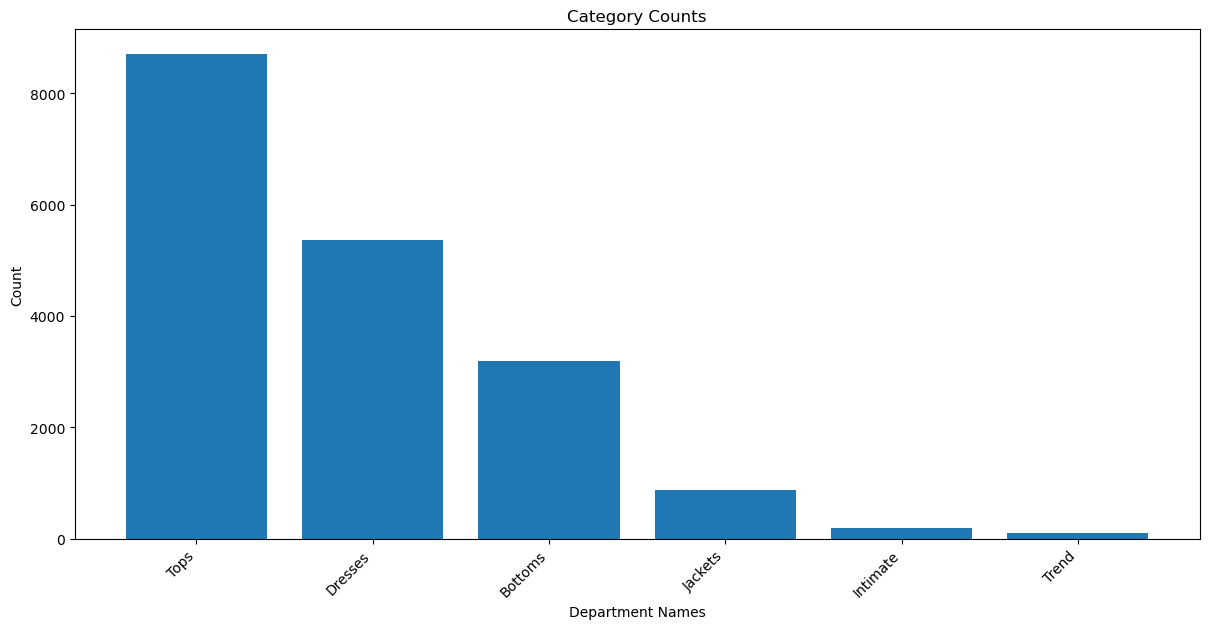

In [9]:
plt.figure(figsize=(12, 6))

counts = dict(sorted(Counter(df['Department Name']).items(),
                     key=lambda x: x[1], reverse=True))

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.xlabel("Department Names")
plt.ylabel("Count")
plt.title("Category Counts")

plt.show()

__We see that the prime department listed in the reviews is Tops followed by Dresses and Bottoms.__

## Build Pipelines
__First we build Numerical pipeline using SimpleImputer and MinMaxScaler.
We use SimpleImputer and stragety='mean' because data is normal distriution and normal.
We then using MinMaxScaler because this is useful for classification models and logistic regression.__


In [10]:
# Define a pipeline for the numerical features
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

num_pipeline = Pipeline([
    (
        'Imputer',
        SimpleImputer(strategy='mean'),
    ),
    (
        'Scaler',
        MinMaxScaler(),
    ),
])
num_pipeline

Pipeline(steps=[('Imputer', SimpleImputer()), ('Scaler', MinMaxScaler())])

__Next we build Catagorical pipeline using OrdinalEncoder, SimpleImputer, and OneHotEncoder__


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
     (
        'Imputer',
        SimpleImputer(strategy='most_frequent')
     ),
     (
        'Cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore'
        )
     ),
])

cat_pipeline

Pipeline(steps=[('Imputer', SimpleImputer(strategy='most_frequent')),
                ('Cat_encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [12]:
# import spaCy
import spacy
nlp = spacy.load("en_core_web_sm")

__This code defines a custom text preprocessing transformer that can plug directly into an scikit-learn pipeline. It uses spaCy to clean and normalize text data.__

In [13]:
# Build a custom text preprocessing transformer.
from sklearn.base import BaseEstimator, TransformerMixin
import spacy


class SpacyPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, model='en_core_web_sm'):
        self.model = model
        self.nlp = spacy.load(model, disable=["parser", "ner"])

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [
            " ".join(
                token.lemma_.lower()
                for token in self.nlp(str(doc))
                if not token.is_stop and not token.is_punct
            )
            for doc in X
        ]

__This code builds a text-processing pipeline using scikit-learn. It chains together two steps: cleaning text with spaCy and converting it into numerical features (TF-IDF).__

In [14]:
# import TfidVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Build the text_pipeline using spacy and tdif
text_pipeline = Pipeline([
    ("spacy", SpacyPreprocessor()),
    ("tfidf", TfidfVectorizer(max_features=2000))
])

__Now we use a ColumnTranformer. This code builds a combined preprocessing system that handles different types of columns in a dataset (numerical, categorical, and text) all at once.  We use this to combine our numerical pipeline, catagorical pipeline, and text pipeline.__

In [15]:
# Import ColumnTransformer
from sklearn.compose import ColumnTransformer

# Build the preprocess columntransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
    ("text", text_pipeline, "Review Text")
])

__Below we look at the class distribution for our y_train.   As mentioned earlier there is a significant class imbalance that will have to be dealt with.__

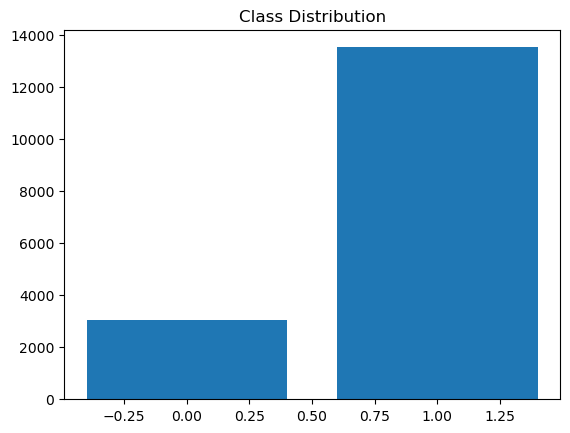

In [16]:
# Produce a histogram to look at the y_train distribution
import numpy as np
import matplotlib.pyplot as plt

y = np.array(y_train)

values, counts = np.unique(y, return_counts=True)

plt.bar(values, counts)
plt.title("Class Distribution")
plt.show()

__Clear class imbalance with significantly more 1 than 0.__

## Training Pipeline


__We train our pipeline, implementing our preprocessor and using LogisticRegression.__

In [17]:
# import LogisticRegresion from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# build model_pileline using preprocessor and Logistic Regression
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer()),
                                                                  ('Scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Clothing ID', 'Division Name', 'Department Name', 'Class Name'], dtype='object')),
                                                 ('text',
                                                  Pipeline(steps=[('spacy',
                                                                   SpacyPreprocessor()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=2000))]),
                                                  'Review Text')])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [18]:
# import accuracy_score
from sklearn.metrics import accuracy_score

y_pred_pipeline = model_pipeline.predict(X_test)
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)

# print the accuracy of our logistic regression model
print('Accuracy:', accuracy_pipeline)

Accuracy: 0.8775067750677507


__Accuracy looks good but is not accurate because of the class imbalance__

In [19]:

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_pipeline,
    target_names=["Not Recommended", "Recommended"]
))

                 precision    recall  f1-score   support

Not Recommended       0.73      0.48      0.58       327
    Recommended       0.90      0.96      0.93      1518

       accuracy                           0.88      1845
      macro avg       0.82      0.72      0.76      1845
   weighted avg       0.87      0.88      0.87      1845



__Result show poor recall (0.48) for Not Recommended (0) due to class imbalance.__

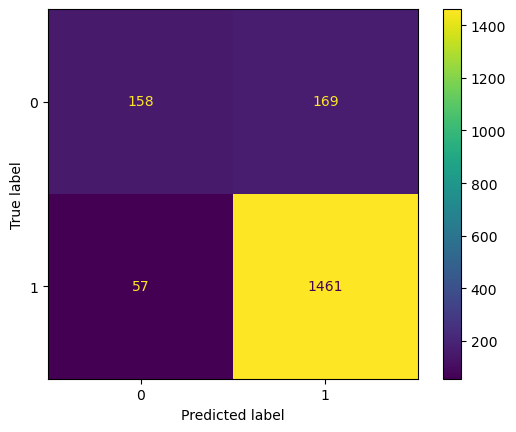

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_pipeline)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

__We have many false positives (169) were bad reviews were labeled as good.__

## Fine-Tuning Pipeline
__We use Cross-validation and Hyperparameter tuning to improve the model.__

In [21]:
from sklearn.model_selection import RandomizedSearchCV

# TODO: set parameters to randomly search over
# A couple parameters with 2-5 options each is plenty


my_distributions = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}


param_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=my_distributions,
    n_iter=6,     # Try 6 different combinations of parameters
    cv=5,         # Use 5-fold cross-validation
    n_jobs=-1,    # Use all available processors (for multiprocessing)
    refit=True,   # Refit the model using the best parameters found
    verbose=3,    # Output of parameters, score, time
    random_state=27,
    scoring="f1_macro"
)

param_search.fit(X_train, y_train)

# Retrieve the best parameters
param_search.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


{'classifier__class_weight': 'balanced', 'classifier__C': 1}

In [22]:
from sklearn.metrics import classification_report

best_model = param_search.best_estimator_

print("Best params:", param_search.best_params_)

y_pred = best_model.predict(X_test)
print("\nDefault threshold (0.5):")
print(classification_report(y_test, y_pred))

Best params: {'classifier__class_weight': 'balanced', 'classifier__C': 1}

Default threshold (0.5):
              precision    recall  f1-score   support

           0       0.54      0.82      0.65       327
           1       0.96      0.85      0.90      1518

    accuracy                           0.84      1845
   macro avg       0.75      0.83      0.77      1845
weighted avg       0.88      0.84      0.85      1845



__Results at 0.5 Threshold are not optimal due to class imbalance.  When model predicts a 0 it is only correct 54% of the time.  (precision = 0.54)__

## Threshold Tuning

__To improve model and compensate for class imbalance we investigate threshold tuning.   Below we look at thresholds from 0.5 to 0.2__

In [23]:

from sklearn.metrics import classification_report

y_probs = param_search.best_estimator_.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.35, 0.2]:
    print(f"\nThreshold {t}")
    print(classification_report(y_test, (y_probs >= t).astype(int)))


Threshold 0.5
              precision    recall  f1-score   support

           0       0.54      0.82      0.65       327
           1       0.96      0.85      0.90      1518

    accuracy                           0.84      1845
   macro avg       0.75      0.83      0.77      1845
weighted avg       0.88      0.84      0.85      1845


Threshold 0.4
              precision    recall  f1-score   support

           0       0.60      0.75      0.67       327
           1       0.94      0.89      0.92      1518

    accuracy                           0.87      1845
   macro avg       0.77      0.82      0.79      1845
weighted avg       0.88      0.87      0.87      1845


Threshold 0.35
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       327
           1       0.94      0.91      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.81      0.80      1845
weighted avg       0.88     

__Best results are using Threshold = 0.35.  Best overall balance with macro F1=0.80, best accuracy (0.88), Strong class 1 dectection (0.93), and 
maintains class 0 performance.__

## Final Predictions 

__Final model predictons using 0.35 threshold.__

In [24]:

from sklearn.metrics import classification_report

# get probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]

# apply chosen threshold
threshold = 0.35
y_pred = (y_probs > threshold).astype(int)

# evaluate
print(f"===== Threshold: {threshold} =====")
print(classification_report(y_test, y_pred))

===== Threshold: 0.35 =====
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       327
           1       0.94      0.91      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.81      0.80      1845
weighted avg       0.88      0.88      0.88      1845



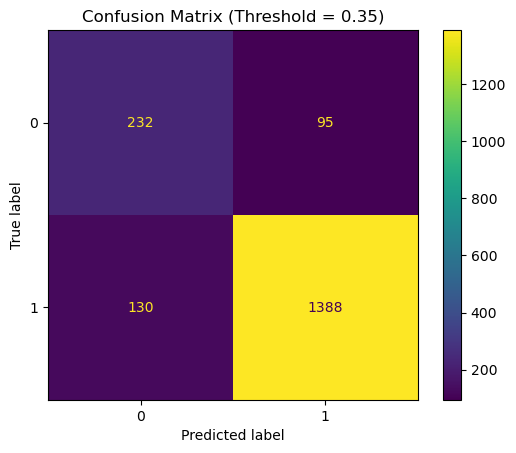

In [25]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# get probabilities (make sure this is your tuned model)
y_probs = param_search.best_estimator_.predict_proba(X_test)[:, 1]

# apply your chosen threshold
threshold = 0.35   # the new preferred value
y_pred_custom = (y_probs >= threshold).astype(int)

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred_custom)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()

__At a threshold of 0.35, the model correctly identifies most positives (1388) with relatively few misses (130), while maintaining a reasonable balance on the negative class (232 correct vs 95 false positives). Overall, it achieves strong, balanced performance with high accuracy and fewer missed important cases compared to higher thresholds.__